<spen style="color:blue;">**Intro and Objectives**</span>

This project aims to analyze two datasets related to a Portuguese bank marketing campaign.
The main objective is to understand the factors associated with customers’ product subscription success. 
The datasets contain information such as customer demographics, service seniority, customer behaviour, and marketing campaign interactions.These will be used to understand factors influencing customer subscription success. 

This script is structured in 4 phases:
1. Load and data verification
   - Import the two datasets to perform initial checks. Ensure the data has been loaded correctly and is ready for analysis.
2. Data cleaning and transformation
   - Assess and prepare the datasets by resolving data quality issues, ensuring consistency across variables, standardizing formats, and applying necessary transformations to facilitate the analysis.
3. Data merge
   - Combine the two cleaned datasets into a single dataframe. Save the new dataset.
4. Data description and findings
   - Explore and summarize the integrated dataset to identify the factors related to customer subscription success.
5. Final conclusions
   - Summarize the key findings and highlight the main insights.

<span style="color:yellow;">**Part 1 Load and Verify data**</span>
- Import pandas
- Import data 
- Verify data
   - data understanding: 
    sample; head or tail; info; describe (for statistic data); isnull; duplicated;

In [1433]:
# import pandas and data 

import pandas as pd
import numpy as np

bank = pd.read_csv(r"C:\Users\cecim\Desktop\VAI DAR CERTO\ThePower\5. Python for Data\Pandas\Proyecto Python for Data\bank-additional.csv")

# the excel has 3 sheets. Ensure to import each
customer = pd.read_excel(r"C:\Users\cecim\Desktop\VAI DAR CERTO\ThePower\5. Python for Data\Pandas\Proyecto Python for Data\customer-details.xlsx",
                         sheet_name= ["2012", "2013", "2014"])

<span style="color:yellow;">**BANK DATA ANALYSIS**</span>

Data related to the marketing campaign

In [1434]:
# Verify bank data

display(bank.head())

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


**Observation:**
Total rows: 43.000
Total columns: 24

In [1435]:
# verify nulls or blanks
bank.isnull().sum()

Unnamed: 0           0
age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

In [1436]:
# Check for duplicates 
bank.duplicated().sum()

np.int64(0)

**Observation:**
No duplicates found

In [1437]:
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  str    
 3   marital         42915 non-null  str    
 4   education       41193 non-null  str    
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  str    
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  str    
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  str    
 16  cons.conf.idx   43000 non-null  str    
 17  euribor3m       33744 non-null  str    
 1

**Observation:**
It has been identified numerical values formatted as string. 
This can cause problems moving forward for data transformation and/or calculation needed.
Also, it is noticed some irrelevant columns that can be removed.

<span style="color:yellow;">**Part 2 Cleaning and transformation**</span>

- Remove unnecessary columns: "Unnamed:0"; "latitude": "longitude"
- Add custom column: "contact_month"; "contact_year"
- Transform numerical entries from string to float
- Convert 1 to "yes", and 0 to "no" for relevant columns
- Change column name "y" to "Subscription"
- Group age into categories: Young = 0 to 30; Adult = 31 to 50; Senior = > 51 
- Group campaign by categories of outreach: 1 Contact; 2 to 3 Contacts; 4 to 5 Contacts; 6 to 10 Contatcs; over 10 Contacts;
- Create category for call duration: short; medium; long; very long;
- Understand nulls for decision making:
  - How many nulls have been idenfitided? Can these compromise the data analysis moving forward? 
  - What strategy can be made in order to reduce analysis impact? 
     - For example, check the % of nulls identified. If over 25%, verify it further if the use of this data is essential for the business and the analysis. 
     - For lower % result, use the options to fill in the data with the median for numerical values; and mode for strings.
     

In [1438]:
# remove non necessary column 
bank.drop(columns=["Unnamed: 0"], inplace=True)
bank.drop(columns=["latitude"], inplace=True)
bank.drop(columns=["longitude"], inplace=True)


In [1439]:
# rename column 

bank.rename(columns={"y": "Subscription"}, inplace=True)

In [1440]:
# Reformat numerical values from string to float 

numeric_cols = [
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

for col in numeric_cols:
    bank[col] = (
        bank[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    
    bank[col] = pd.to_numeric(bank[col], errors="coerce")

In [1441]:
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             37880 non-null  float64
 1   job             42655 non-null  str    
 2   marital         42915 non-null  str    
 3   education       41193 non-null  str    
 4   default         34019 non-null  float64
 5   housing         41974 non-null  float64
 6   loan            41974 non-null  float64
 7   contact         43000 non-null  str    
 8   duration        43000 non-null  int64  
 9   campaign        43000 non-null  int64  
 10  pdays           43000 non-null  int64  
 11  previous        43000 non-null  int64  
 12  poutcome        43000 non-null  str    
 13  emp.var.rate    43000 non-null  float64
 14  cons.price.idx  42529 non-null  float64
 15  cons.conf.idx   43000 non-null  float64
 16  euribor3m       33744 non-null  float64
 17  nr.employed     43000 non-null  float64
 1

In [1442]:
# reformat float replies into yes, no, unkown

bank["default"] = (
    bank["default"]
    .map({
        1.0: "YES",
        0.0: "NO"
    })
    .fillna("UNKNOWN")
)


bank["loan"] = (
    bank["loan"]
    .map({
        1.0: "YES",
        0.0: "NO"
    })
    .fillna("UNKNOWN")
)

bank["housing"] = (
    bank["housing"]
    .map({
        1.0: "YES",
        0.0: "NO"
    })
    .fillna("UNKNOWN")
)

In [1443]:
# group campaign into outreach categories

bins = [0, 1, 3, 5, 10, 55]

labels = [
    "1 contact",
    "2-3 contacts",
    "4-5 contacts",
    "6-10 contacts",
    "11+ contacts"
]

bank["campaign_group"] = pd.cut(
    bank["campaign"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [1444]:
bank["duration"].describe()

count    43000.000000
mean       257.739279
std        258.666033
min          0.000000
25%        102.000000
50%        179.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

In [1445]:
# call duration categories
# categories were defined based on quartiles

def duration_group(duration):
    if duration <= 102:
        return "Short"
    elif duration <= 179:
        return "Medium"
    elif duration <= 319:
        return "Long"
    else:
        return "Very Long"

bank["duration_group"] = bank["duration"].apply(duration_group)

position = bank.columns.get_loc("duration")
column = bank.pop("duration_group")
bank.insert(position + 1, "duration_group", column)

In [1446]:
# for nulls, to understand further, verify the % of nulls to best judge the decision making (removall of rows or fill nulls)

null_percent = (bank.isnull().sum() / len(bank)) * 100
null_percent = null_percent[null_percent > 0]
print(null_percent)

age               11.906977
job                0.802326
marital            0.197674
education          4.202326
cons.price.idx     1.095349
euribor3m         21.525581
date               0.576744
campaign_group     0.002326
dtype: float64


Decision making for data cleaning and transformation
- Considering the % result of nulls, it is suggested the following:
  - For numerical columns it is suggested to fill in using the median to reduce the effect of outliers; 
  - For "job", "marital", and "education", it is suggested to fill using mode, as these are categories (string type could not be calculated using median)
  - "date" represents an insignificant % of missing data. In this case, it can be suggested to remove rows with missing data.   


In [1447]:
# fill in categories

bank["job"] = bank["job"].fillna(bank["job"].mode()[0])
bank["marital"] = bank["marital"].fillna(bank["marital"].mode()[0])
bank["education"] = bank["education"].fillna(bank["education"].mode()[0])


In [1448]:
# remove nulls under "date" column (minium impact based on % result) 
# 248 rows will be removed

bank = bank.dropna(subset=["date"])

# after this change we should have a total of 42.752 rows

In [1449]:
bank["age"] = bank["age"].fillna(bank["age"].median())
bank["cons.price.idx"] = bank["cons.price.idx"].fillna(bank["cons.price.idx"].median())
bank["euribor3m"] = bank["euribor3m"].fillna(bank["euribor3m"].median())

In [1450]:
bank["age"].describe()

count    42752.000000
mean        39.745018
std          9.822489
min         17.000000
25%         33.000000
50%         38.000000
75%         46.000000
max         98.000000
Name: age, dtype: float64

In [1451]:
# Group age 

def age_group(age):
    if age <= 30:
        return "Young"
    elif age <= 50:
        return "Adult"
    else:
        return "Senior"

# Create the new column
bank["age_group"] = bank["age"].apply(age_group)

# Move it next to the age column
age_position = bank.columns.get_loc("age")
column = bank.pop("age_group")
bank.insert(age_position + 1, 'age_group', column)

In [1452]:
# Data verification
bank.isnull().sum()

age               0
age_group         0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
duration          0
duration_group    0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
Subscription      0
date              0
id_               0
campaign_group    1
dtype: int64

In [1453]:
# add "month" and " year column"
# For that it is needed to convert the date column, however Python migth not recognise the Spanish format. 

months= {
    "enero": "January",
    "febrero": "February",
    "marzo": "March",
    "abril": "April",
    "mayo": "May",
    "junio": "June",
    "julio": "July",
    "agosto": "August",
    "septiembre": "September",
    "octubre": "October",
    "noviembre": "November",
    "diciembre": "December"
}

for esp, eng in months.items():
    bank["date"] = bank["date"].str.replace(esp, eng)

bank["date"] = pd.to_datetime(bank["date"])

In [1454]:
bank["contact_month_name"] = bank["date"].dt.month_name()

bank["contact_year"] = bank["date"].dt.year


In [1455]:
bank.head()

,age,age_group,job,marital,education,default,housing,loan,contact,duration,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,Subscription,date,id_,campaign_group,contact_month_name,contact_year
0,38.0,Adult,housemaid,MARRIED,basic.4y,NO,NO,NO,telephone,261,...,93.994,-36.4,4.857,5191.0,no,2019-08-02,089b39d8-e4d0-461b-87d4-814d71e0e079,1 contact,August,2019
1,57.0,Senior,services,MARRIED,high.school,UNKNOWN,NO,NO,telephone,149,...,93.994,-36.4,4.857,5191.0,no,2016-09-14,e9d37224-cb6f-4942-98d7-46672963d097,1 contact,September,2016
2,37.0,Adult,services,MARRIED,high.school,NO,YES,NO,telephone,226,...,93.994,-36.4,4.857,5191.0,no,2019-02-15,3f9f49b5-e410-4948-bf6e-f9244f04918b,1 contact,February,2019
3,40.0,Adult,admin.,MARRIED,basic.6y,NO,NO,NO,telephone,151,...,93.994,-36.4,4.857,5191.0,no,2015-11-29,9991fafb-4447-451a-8be2-b0df6098d13e,1 contact,November,2015
4,56.0,Senior,services,MARRIED,high.school,NO,NO,YES,telephone,307,...,93.994,-36.4,4.857,5191.0,no,2017-01-29,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,1 contact,January,2017


In [1456]:
bank["age_group"].value_counts()

age_group
Adult     29397
Young      6830
Senior     6525
Name: count, dtype: int64

<span style="color:green;">**CUSTOMER DATA ANALYSIS**</span>

Data related to Customers' behaviour, service seniority, social and household indicators.

In [1457]:
customer = pd.read_excel(r"C:\Users\cecim\Desktop\VAI DAR CERTO\ThePower\5. Python for Data\Pandas\Proyecto Python for Data\customer-details.xlsx",
                         sheet_name= ["2012", "2013", "2014"])

customer = pd.concat(customer.values(), ignore_index= True) 
# this step was necessary in order to merge into one dataframe the 3 sheets available in the excel

In [1458]:
customer.tail()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
43165,14085,156980,1,2,2014-05-17,7,5f432048-d515-4bb5-9c94-62db451f88d4
43166,14086,139820,0,0,2014-09-29,1,993bbbd6-4dbc-4a40-a408-f91f8462bee6
43167,14087,78470,2,2,2014-10-28,12,d6271666-319d-42c8-a741-cb22bf2c2093
43168,14088,144218,0,1,2014-07-01,9,f67fbfa8-6573-414d-a805-b26a2f1b1ceb
43169,14089,115155,0,2,2014-12-25,7,9727bc06-c11a-461a-a5bb-3d210467cc2a


In [1459]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         43170 non-null  int64         
 1   Income             43170 non-null  int64         
 2   Kidhome            43170 non-null  int64         
 3   Teenhome           43170 non-null  int64         
 4   Dt_Customer        43170 non-null  datetime64[us]
 5   NumWebVisitsMonth  43170 non-null  int64         
 6   ID                 43170 non-null  str           
dtypes: datetime64[us](1), int64(5), str(1)
memory usage: 2.3 MB


**Observation:**
Data types correspond correctly to entries.
No changes to be applied at this instance. 

In [1460]:
customer.isnull().sum()

Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

Comments about data transformation and data cleaning needed: 
- No nulls were identified;
- One unnecessary column to be removed: "Unnamed: 0";
- Add new column for "total nr. children" ("Kidhome" + "Teenhome") in order to provide a more comprehensive household composition indicator for the analysis;
- Add new column for year of client joining. This can be used to to measure customer seniority and assess whether longer tenured customers exhibited higher subscription conversion rates.
- Group income into categories as "Low", "Medium", "High". Use describe() to understand the range of categories. 
- Define categories for number of web visits by client

In [1461]:
# remove column

customer.drop(columns=["Unnamed: 0"], inplace=True)

In [1462]:
# add column 

total_children = customer["Kidhome"] + customer["Teenhome"]
customer["Nr Children home"] = total_children

In [1463]:
customer.head()

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,Nr Children home
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,1
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,2
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,2
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,3
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,3


In [1464]:
# Add column for year based on dt_Customer

customer["Year_entry"] = customer["Dt_Customer"].dt.year

In [1465]:
customer.head()

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,Nr Children home,Year_entry
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,1,2012
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,2,2012
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,2,2012
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,3,2012
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,3,2012


In [1466]:
customer.describe().round(0)

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,Nr Children home,Year_entry
count,43170.0,43170.0,43170.0,43170,43170.0,43170.0,43170.0
mean,93227.0,1.0,1.0,2013-05-11 22:09:47.407922,17.0,2.0,2013.0
min,5841.0,0.0,0.0,2012-01-01 00:00:00,1.0,0.0,2012.0
25%,49608.0,0.0,0.0,2012-07-16 00:00:00,9.0,1.0,2012.0
50%,93010.0,1.0,1.0,2013-03-01 00:00:00,17.0,2.0,2013.0
75%,136740.0,2.0,2.0,2014-03-28 00:00:00,25.0,3.0,2014.0
max,180802.0,2.0,2.0,2014-12-31 00:00:00,32.0,4.0,2014.0
std,50498.0,1.0,1.0,NaN,9.0,1.0,1.0


In [1467]:
# Group income

def income_group(income):
    if income < 50000:
        return "Low"
    elif income < 100000:
        return "Median"
    else:
        return "High"

# Create the new column
customer["income_group"] = customer["Income"].apply(income_group)

# Move the new column next to the income column
income_position = customer.columns.get_loc("Income")
column = customer.pop("income_group")
customer.insert(income_position + 1, "income_group", column)

print(customer[["Income", "income_group"]].head())

   Income income_group
0  161770         High
1   85477       Median
2  147233         High
3  121393         High
4   63164       Median


In [1468]:
# number of web visit - activy 

customer["NumWebVisitsMonth"].describe()

count    43170.000000
mean        16.591290
std          9.241769
min          1.000000
25%          9.000000
50%         17.000000
75%         25.000000
max         32.000000
Name: NumWebVisitsMonth, dtype: float64

In [1469]:
def web_activity(visits):
    if visits <= 9:
        return "Low Activity"
    elif visits <= 17:
        return "Medium Activity"
    elif visits <= 25:
        return "High Activity"
    else:
        return "Very High Activity"

customer["web_activity"] = customer["NumWebVisitsMonth"].apply(web_activity)

In [1470]:
customer["web_activity"].value_counts()

web_activity
Low Activity          11959
Medium Activity       10840
High Activity         10778
Very High Activity     9593
Name: count, dtype: int64

<span style="color:yellow;">**Part 3 Data Merge**</span>

Join the two datasets for further analysis and final conclusions

In [1471]:
campaign = bank.merge(customer, left_on="id_", right_on= "ID", how= "left")
campaign.head()

,age,age_group,job,marital,education,default,housing,loan,contact,duration,...,Income,income_group,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,Nr Children home,Year_entry,web_activity
0,38.0,Adult,housemaid,MARRIED,basic.4y,NO,NO,NO,telephone,261,...,161770,High,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,1,2012,Very High Activity
1,57.0,Senior,services,MARRIED,high.school,UNKNOWN,NO,NO,telephone,149,...,85477,Median,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,2,2012,Low Activity
2,37.0,Adult,services,MARRIED,high.school,NO,YES,NO,telephone,226,...,147233,High,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,2,2012,Low Activity
3,40.0,Adult,admin.,MARRIED,basic.6y,NO,NO,NO,telephone,151,...,121393,High,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,3,2012,Very High Activity
4,56.0,Senior,services,MARRIED,high.school,NO,NO,YES,telephone,307,...,63164,Median,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,3,2012,High Activity


In [1472]:
# save new dataframe merged 
campaign.to_csv("campaign_final.csv", index=False)

<spen style="color:yellow;">**Part 4 Data description and Visualizations**</spen>

This section presents the exploratory analysis of the merged dataset through descriptive statistics and visualizations. The objective is to identify the main factors associated with customer subscription success.

The analysis is structured into three areas:

4.1 Demographic Factors
 - The following customer characteristics will be analysed against the subscription conversion rate:
   - Age group
   - Occupation (job)
   - Marital status
   - Education level

4.2 Economic Factors and customer profile
 - The following indicators will be analysed:
   - Income group
   - Loand and housing services
   - Number of children in the household
   - Customer seniorty 
   - Customer web visits

4.3 Marketing Campaign Factors
 - The following campaign related indicators will be assessed:
   - Contact method
   - Number of contacts made during the campaign
   - Call duration
   - Previous campaign contacts and outcomes

The analysis aims to identify which factors are associated with higher subscription conversion rates and to evaluate the overall effectiveness of the marketing campaign.
To support the analysis, visualizations and charts will be created using Python libraries such as Matplotlib and Seaborn.

In [1473]:
# Import visualizations libraries

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

<spend style="color:orange;">**4.1 Overall Campaign Success rate**</spen>

Verify the overall subscription total and conversion rate achieved by the marketing campaign.
This initial analysis provides an overview of the campaign's effectiveness and establishes a baseline for understanding customer subscription behaviour. The results serve as a starting point for identifying the demographic, economic, and marketing-related factors that may have influenced subscription outcomes.

In [1474]:
campaign.info()

<class 'pandas.DataFrame'>
RangeIndex: 42752 entries, 0 to 42751
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   age                 42752 non-null  float64       
 1   age_group           42752 non-null  str           
 2   job                 42752 non-null  str           
 3   marital             42752 non-null  str           
 4   education           42752 non-null  str           
 5   default             42752 non-null  str           
 6   housing             42752 non-null  str           
 7   loan                42752 non-null  str           
 8   contact             42752 non-null  str           
 9   duration            42752 non-null  int64         
 10  duration_group      42752 non-null  str           
 11  campaign            42752 non-null  int64         
 12  pdays               42752 non-null  int64         
 13  previous            42752 non-null  int64         
 14  p

In [1475]:
# Subscription success rate
campaign["Subscription"].value_counts(normalize=True)*100

Subscription
no     88.746725
yes    11.253275
Name: proportion, dtype: float64

In [1476]:
# Total 
campaign["Subscription"].value_counts()

Subscription
no     37941
yes     4811
Name: count, dtype: int64

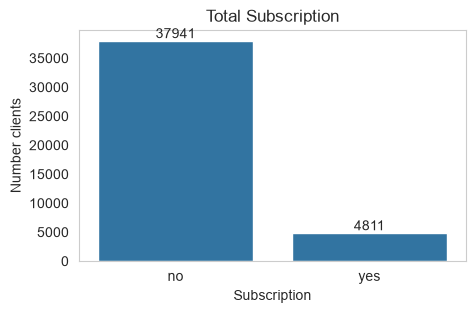

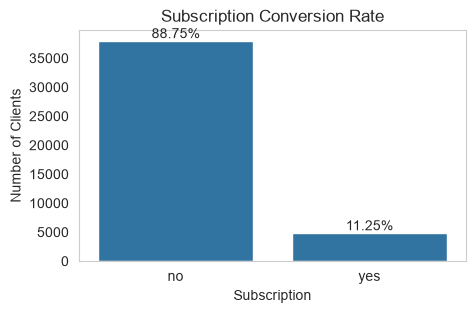

In [ ]:
# Visual 
# Total count of subscription

sns.set_style("whitegrid", {"grid.color": "none"})
plt.figure(figsize=(5,3))

ax = sns.countplot(data=campaign, x="Subscription")

plt.title("Total Subscription")
plt.ylabel("Number clients")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

# % rate of subscription

plt.figure(figsize=(5,3))

ax = sns.countplot(data=campaign, x="Subscription")

total = len(campaign)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(
        f"{percentage:.2f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Subscription Conversion Rate")
plt.ylabel("Number of Clients")

plt.show()

**Observation:**
The subscription results indicate that the marketing campaign achieved a relatively low conversion rate, with the majority of customers (88.75%) choosing not to subscribe to the campaign's product.

<spend style="color:orange;">**4.2 Demographics factors**</spen>

The following analysis focuses on key customer demographic characteristics, including age group, marital status, occupation, and education level, to assess their potential influence on subscription outcomes and identify customer segments with higher conversion rates.

In [1478]:
# Subscription by age group

age_total = pd.crosstab(campaign["age_group"],campaign["Subscription"])
age_total

Subscription,no,yes
age_group,,
Adult,26595,2802
Senior,5540,985
Young,5806,1024


In [1479]:
age_sub = (pd.crosstab(campaign["age_group"],campaign["Subscription"],normalize="index") * 100)
age_sub

Subscription,no,yes
age_group,,
Adult,90.468415,9.531585
Senior,84.904215,15.095785
Young,85.007321,14.992679


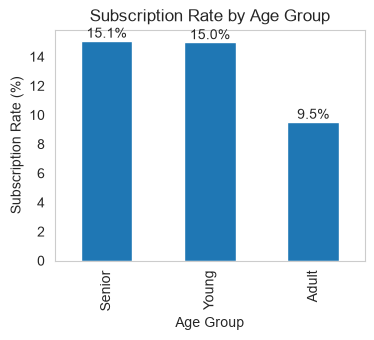

In [1480]:
# Visual age
plt.figure(figsize=(4,3))

ax = age_sub["yes"].sort_values(ascending=False).plot(kind="bar")

plt.title("Subscription Rate by Age Group")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("Age Group")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [1518]:
campaign["age"].describe()

count    42752.000000
mean        39.745018
std          9.822489
min         17.000000
25%         33.000000
50%         38.000000
75%         46.000000
max         98.000000
Name: age, dtype: float64

Comment: max age 98 seems a little off compared to the avarge and the quartiles. It would be relevant to investigate a possibility of outlier.

In [ ]:
# Verify possible outlier (max age indicated seems off)
Q1 = campaign["age"].quantile(0.25)
Q3 = campaign["age"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Lower limit: 13.5
Upper limit: 65.5


In [ ]:
# Check for total outlier and age 
outliers_age = campaign[
    (campaign["age"] < lower_limit) |
    (campaign["age"] > upper_limit)
]

print("Number of outliers:", len(outliers_age))


campaign.loc[
    campaign["age"] > upper_limit,
    "age"
].value_counts().sort_index()

Number of outliers: 576


age
66.0    53
67.0    21
68.0    28
69.0    33
70.0    40
71.0    50
72.0    35
73.0    35
74.0    30
75.0    20
76.0    27
77.0    19
78.0    28
79.0    13
80.0    31
81.0    19
82.0    18
83.0    17
84.0     5
85.0    14
86.0     7
87.0     1
88.0    20
89.0     2
91.0     2
92.0     4
94.0     1
95.0     1
98.0     2
Name: count, dtype: int64

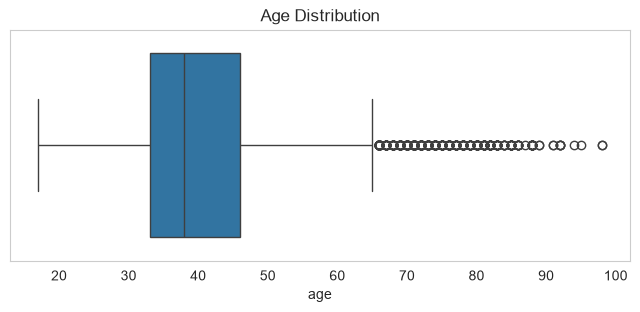

In [1523]:
# visual

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))
sns.boxplot(x=campaign["age"])

plt.title("Age Distribution")
plt.show()

**Observation**: 
The average client age is 39. Using the IQR method, customers older than approximately 66 years are statistically classified as outliers. However, these observations likely represent genuine customer records rather than data quality issues. Therefore, they were retained in the analysis, as older customers may constitute an important customer segment for term deposit subscriptions.
Considering the above mentioned, the analysis indicates that both Young and Senior customers achieved substantially higher subscription conversion rates than Adult customers. While Senior customers recorded the highest conversion rate (15.1%), the difference compared to Young customers (15.0%) is minimal. In contrast, Adult customers exhibited the lowest conversion rate (9.5%), suggesting that younger and older customer segments were more receptive to the marketing campaign.

In [1481]:
# Subscription by job type 

job_type = (pd.crosstab(campaign["job"],campaign["Subscription"],normalize="index") * 100)
job_type

Subscription,no,yes
job,,
admin.,87.071595,12.928405
blue-collar,93.107756,6.892244
entrepreneur,91.782638,8.217362
housemaid,90.062668,9.937332
management,88.866930,11.133070
retired,74.747475,25.252525
self-employed,89.143628,10.856372
services,91.946796,8.053204
student,68.638393,31.361607


In [1482]:
job_total = pd.crosstab(campaign["job"],campaign["Subscription"])
job_total

Subscription,no,yes
job,,
admin.,9705,1441
blue-collar,8943,662
entrepreneur,1385,124
housemaid,1006,111
management,2698,338
retired,1332,450
self-employed,1322,161
services,3802,333
student,615,281


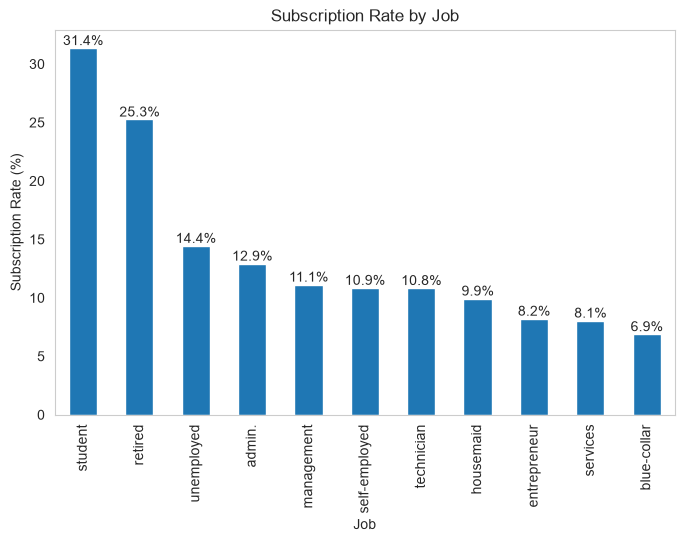

In [1483]:
# Visual job
plt.figure(figsize=(8,5))

ax = job_type["yes"].sort_values(ascending=False).plot(kind="bar")

plt.title("Subscription Rate by Job")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("Job")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

**Observation:**
Students represent the customer segment with the highest subscription conversion rate, followed by retired customers. These findings could be considered as consistent with the results observed in the age group analysis, where younger and older customers demonstrated higher conversion rates than other age categories. On the other hand, the lowest conversion rate was observed among the adult category, which aligns with the lower subscription rates identified for occupations that are predominantly represented within this age group.

In [1484]:
# Subscription by marital status

marital_status = (pd.crosstab(campaign["marital"],campaign["Subscription"],normalize="index") * 100)
marital_status

Subscription,no,yes
marital,,
DIVORCED,89.820234,10.179766
MARRIED,89.797493,10.202507
SINGLE,86.058291,13.941709


In [1485]:
marital_total = pd.crosstab(campaign["marital"],campaign["Subscription"])
marital_total

Subscription,no,yes
marital,,
DIVORCED,4297,487
MARRIED,23280,2645
SINGLE,10364,1679


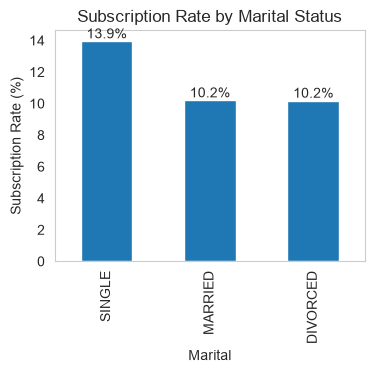

In [ ]:
# Visual marital status
plt.figure(figsize=(4,5))

ax = marital_status["yes"].sort_values(ascending=False).plot(kind="bar")

plt.title("Subscription Rate by Marital Status")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("Marital")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

**Obsrsvation:** 
Customers in the single segment achieved the highest subscription conversion rate. This result is consistent with the age group and occupation analyses, where younger customers and students also exhibited higher conversion rates. Together, these findings indicate a potential relationship between customer life stage and subscription behaviour.

In [1487]:
# Subscription by education

education_total = pd.crosstab(campaign["education"],campaign["Subscription"])
education_total

Subscription,no,yes
education,,
basic.4y,3883,448
basic.6y,2180,194
basic.9y,5793,488
high.school,8802,1070
illiterate,14,4
professional.course,4821,619
university.degree,12448,1988


In [1488]:
education = (pd.crosstab(campaign["education"],campaign["Subscription"],normalize="index") * 100)
education

Subscription,no,yes
education,,
basic.4y,89.655969,10.344031
basic.6y,91.828138,8.171862
basic.9y,92.230537,7.769463
high.school,89.161264,10.838736
illiterate,77.777778,22.222222
professional.course,88.621324,11.378676
university.degree,86.228872,13.771128


**Observation:** Illiterate segment show a higher % rate, although the sample size is quite minimum. 18 total. 
This must be taken into consideration for the analysis.

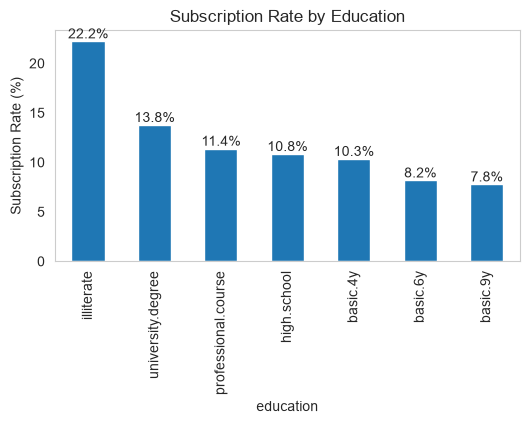

In [1489]:
# Visual education
plt.figure(figsize=(6,3))

ax = education["yes"].sort_values(ascending=False).plot(kind="bar")

plt.title("Subscription Rate by Education")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("education")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

**Observation:** Although the illiterate segment shows the highest subscription conversion rate, the sample size of 18, it is not representative for the analysis. In this case, excluding the illiterate category due to its limited sample size, customers with higher educational attainment generally exhibit higher subscription rates. University graduates show the highest conversion rate among the major education groups, suggesting a positive relationship between education level and subscription success. 


<spend style="color:orange;">**4.3 Social & Economic factors**</spen>

In this section, the income group; default (clients with unpaid history); loan; housing; number of children; will be considered as the key social and economic factors to assess their potential influence on subscription outcomes and identify customer segments with higher conversion rates. 

In [1491]:
# Subscription by income

income_total = pd.crosstab(campaign["income_group"],campaign["Subscription"])
income_total

Subscription,no,yes
income_group,,
High,17495,2179
Low,9581,1215
Median,10865,1417


In [1492]:
# Subscription by income

income_rate = (pd.crosstab(campaign["income_group"],campaign["Subscription"], normalize= "index") * 100)
income_rate

Subscription,no,yes
income_group,,
High,88.924469,11.075531
Low,88.745832,11.254168
Median,88.462791,11.537209


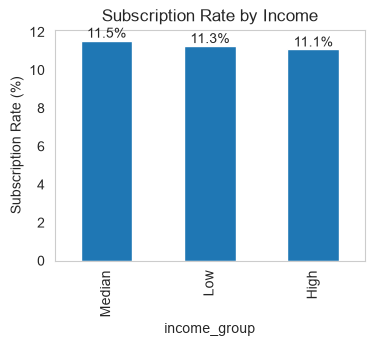

In [1493]:
# Visual income
plt.figure(figsize=(4,3))

ax = income_rate["yes"].sort_values(ascending=False).plot(kind="bar")

plt.title("Subscription Rate by Income")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("income_group")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [1494]:
# Subscription by loan (does not include housing)
# "Yes" it means that the customer has applied for other types of loan 
# "No" it meas that the customer has not applied for othet types of loan 

loan_total = pd.crosstab(campaign["loan"],campaign["Subscription"])
loan_total

Subscription,no,yes
loan,,
NO,31250,3994
UNKNOWN,905,113
YES,5786,704


In [1495]:
loan_rate = (pd.crosstab(campaign["loan"],campaign["Subscription"], normalize= "index") * 100)
loan_rate

Subscription,no,yes
loan,,
NO,88.667575,11.332425
UNKNOWN,88.899804,11.100196
YES,89.152542,10.847458


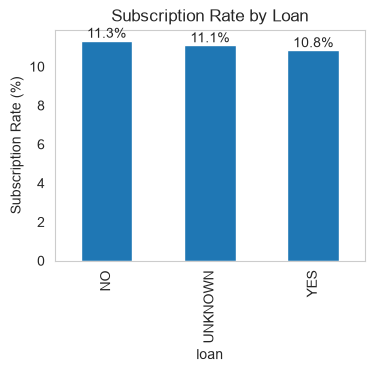

In [1496]:
# Visual Loan
plt.figure(figsize=(4,3))

ax = loan_rate["yes"].sort_values(ascending=False).plot(kind="bar")

plt.title("Subscription Rate by Loan")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("loan")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [1497]:
# Subscription by housing

housing_total = pd.crosstab(campaign["housing"],campaign["Subscription"])
housing_total

Subscription,no,yes
housing,,
NO,17263,2104
UNKNOWN,905,113
YES,19773,2594


In [1498]:
housing_rate = (pd.crosstab(campaign["housing"],campaign["Subscription"], normalize= "index") * 100)
housing_rate

Subscription,no,yes
housing,,
NO,89.136159,10.863841
UNKNOWN,88.899804,11.100196
YES,88.402557,11.597443


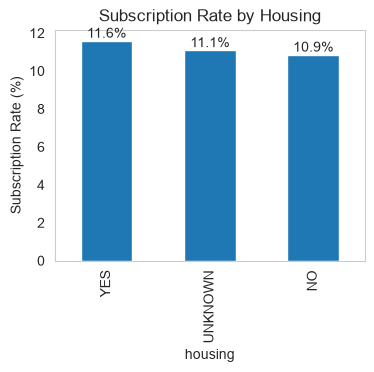

In [1499]:
# Visual housing
plt.figure(figsize=(4,3))

ax = housing_rate["yes"].sort_values(ascending=False).plot(kind="bar")

plt.title("Subscription Rate by Housing")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("housing")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [1500]:

children_total = pd.crosstab(campaign["Nr Children home"],campaign["Subscription"])
children_total

Subscription,no,yes
Nr Children home,,
0,4173,554
1,8429,1016
2,12599,1642
3,8554,1059
4,4186,540


In [1501]:
children_rate = (pd.crosstab(campaign["Nr Children home"],campaign["Subscription"], normalize= "index") * 100)
children_rate

Subscription,no,yes
Nr Children home,,
0,88.280093,11.719907
1,89.242986,10.757014
2,88.469911,11.530089
3,88.983668,11.016332
4,88.573847,11.426153


In [1524]:
default_total = pd.crosstab(campaign["default"],campaign["Subscription"])
default_total

Subscription,no,yes
default,,
NO,29464,4346
UNKNOWN,8474,465
YES,3,0


In [1526]:
default_rate = (pd.crosstab(campaign["default"],campaign["Subscription"], normalize= "index") * 100)
default_rate

Subscription,no,yes
default,,
NO,87.145815,12.854185
UNKNOWN,94.798076,5.201924
YES,100.000000,0.000000


In [1528]:
# check for total of yes to understand further 
campaign["default"].value_counts()

default
NO         33810
UNKNOWN     8939
YES            3
Name: count, dtype: int64

**Observation:** While most socio economic indicators assessed, including income level, housing loans, personal loans, and number of children, showed very similar subscription conversion rates (around 10–11%), the default status presented a noticeably different pattern. Customers with no history of payment default achieved a conversion rate of approximately 12%, compared with only 5.2% for customers with an unknown default status. No successful subscriptions were recorded among customers with a history of payment default. 
It is important to note that, these results initially may suggest that customer with no unpaid history is a stronger indicator of subscription success than other socioe conomic factors, this finding must be interpreted with caution due to severe class imbalance. The "YES" default category contains only 3 customers out of over 42,000 total. Because of this minuscule sample size, the 0% conversion rate for defaulting customers is not statistically reliable and should not be used to drive definitive business logic without further data.

In [1537]:
# Customers service seniority

campaign["Year_entry"].value_counts()


Year_entry
2012    19909
2014    13972
2013     8871
Name: count, dtype: int64

In [1538]:
customer_year_rate = (pd.crosstab(campaign["Year_entry"],campaign["Subscription"], normalize= "index") * 100)
customer_year_rate

Subscription,no,yes
Year_entry,,
2012,95.409111,4.590889
2013,92.289483,7.710517
2014,77.004008,22.995992


**Observation:** Considering the years analysed, the findings show that customers who have recent join the bank has a higher conversion rate compared to senior joiners. The analysis may suggest that the newer the customer, the significantly more receptive they are to the marketing campaign. In fact, customers who joined in 2014 are five times more likely to subscribe than those who joined in 2012.

In [1539]:
# Customers web visits

campaign["web_activity"].value_counts()

web_activity
Low Activity          11848
Medium Activity       10734
High Activity         10674
Very High Activity     9496
Name: count, dtype: int64

In [1540]:
web_activity_rate = (pd.crosstab(campaign["web_activity"],campaign["Subscription"], normalize= "index") * 100)
web_activity_rate

Subscription,no,yes
web_activity,,
High Activity,88.729623,11.270377
Low Activity,88.766036,11.233964
Medium Activity,88.811254,11.188746
Very High Activity,88.668913,11.331087


**Observation:** Based on the analysis results, it is noticed almost 0.15% difference in conversion rates between the least active users (11.23%) and the most active users (11.33%).
In this case, the web activity segment does not seem to be a strong indicator for the subscription coverstion rate.  

<spend style="color:orange;">**4.5 Marketing campaign factors**</spen>

To assess the factors that may have influenced the success of the marketing campaign, the following marketing related indicators will be analysed against the subscription conversion rate: contact method; call duration; number of campaign contacts; the number of contacts made with the customer before the current campaign.
Also, it would be indicated the outcome of the previous marketing campaign involving the customer.
The main purpose is to analyse the effectiveness of the bank's marketing efforts and help explain differences in customer subscription behaviour.


In [1502]:
# Contact method: telephone or mobile

contact_total = pd.crosstab(campaign["contact"],campaign["Subscription"])
contact_total

Subscription,no,yes
contact,,
cellular,23221,4011
telephone,14720,800


In [1503]:
contact_rate = (pd.crosstab(campaign["contact"],campaign["Subscription"], normalize= "index") * 100)
contact_rate

Subscription,no,yes
contact,,
cellular,85.271005,14.728995
telephone,94.845361,5.154639


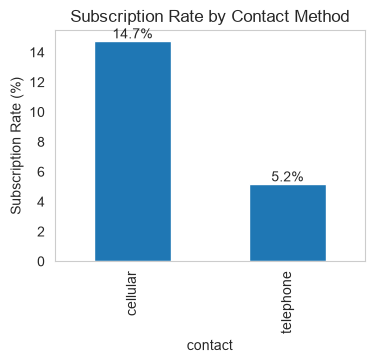

In [1504]:
# Visual contact method
plt.figure(figsize=(4,3))

ax = contact_rate["yes"].sort_values(ascending=False).plot(kind="bar")

plt.title("Subscription Rate by Contact Method")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("contact")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

**Observation:** The cellular contact method achieved a higher subscription conversion rate than telephone. The difference of approximately 9.5 percentage points suggests that customers contacted via mobile devices were more likely to subscribe.
This finding indicates that the communication channel may have played an important role in the effectiveness of the marketing campaign. 

In [1505]:
# Campaign outreach / number of contacts made during the campaign

campaign_total = pd.crosstab(campaign["campaign_group"],campaign["Subscription"])
campaign_total


Subscription,no,yes
campaign_group,,
1 contact,15926,2377
2-3 contacts,14670,1863
4-5 contacts,4034,378
6-10 contacts,2440,166
11+ contacts,870,27


In [1506]:
campaign_rate = (pd.crosstab(campaign["campaign_group"],campaign["Subscription"], normalize= "index") * 100)
campaign_rate

Subscription,no,yes
campaign_group,,
1 contact,87.013058,12.986942
2-3 contacts,88.731628,11.268372
4-5 contacts,91.432457,8.567543
6-10 contacts,93.630084,6.369916
11+ contacts,96.989967,3.010033


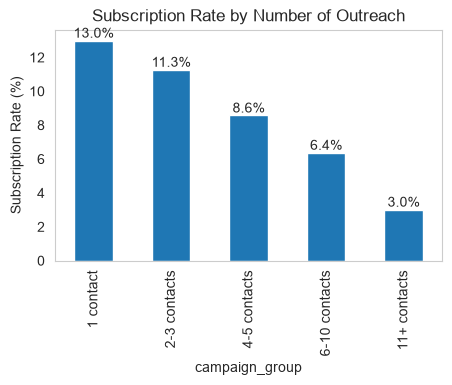

In [1507]:
# Visual campaign number of outreach
plt.figure(figsize=(5,3))

ax = campaign_rate["yes"].sort_values(ascending=False).plot(kind="bar")

plt.title("Subscription Rate by Number of Outreach")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("campaign_group")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [1508]:
# Number of contacts per month during the campaign

campaign["contact_year"].value_counts()


contact_year
2019    8564
2017    8562
2018    8549
2015    8544
2016    8533
Name: count, dtype: int64

In [1509]:
campaign_year = (pd.crosstab(campaign["contact_year"],campaign["Subscription"], normalize= "index") * 100)
campaign_year

Subscription,no,yes
contact_year,,
2015,89.126873,10.873127
2016,88.315950,11.684050
2017,89.032936,10.967064
2018,88.548368,11.451632
2019,88.708547,11.291453


In [1510]:
campaign_month = (pd.crosstab(campaign["contact_month_name"],campaign["Subscription"], normalize= "index") * 100)
campaign_month

Subscription,no,yes
contact_month_name,,
April,88.805137,11.194863
August,88.542258,11.457742
December,88.553531,11.446469
February,88.873358,11.126642
January,88.399204,11.600796
July,88.588923,11.411077
June,88.665913,11.334087
March,89.272778,10.727222
May,89.371300,10.628700


**Observation**: The highest subscription conversion rates were achieved within the first three customer contacts. Customers contacted once recorded the highest conversion rate (13%), while those contacted two to three times achieved conversion rates of approximately 11%, suggesting that campaign effectiveness decreases with repeated outreach.

The number of customer contacts remained stable across the analysed years, indicating that differences in subscription performance are unlikely to be driven by variations in outreach volume.

In [1511]:
# call duration

call_total = pd.crosstab(campaign["duration_group"],campaign["Subscription"])
call_total

Subscription,no,yes
duration_group,,
Long,9591,1123
Medium,10193,488
Short,10627,86
Very Long,7530,3114


In [ ]:
# Find average durantion
campaign["duration"].describe()

count    42752.000000
mean       257.766186
std        258.778698
min          0.000000
25%        102.000000
50%        179.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

In [1513]:
# durantion rate

duration_rate = (pd.crosstab(campaign["duration_group"],campaign["Subscription"], normalize= "index") * 100)
duration_rate

Subscription,no,yes
duration_group,,
Long,89.518387,10.481613
Medium,95.431139,4.568861
Short,99.197237,0.802763
Very Long,70.744081,29.255919


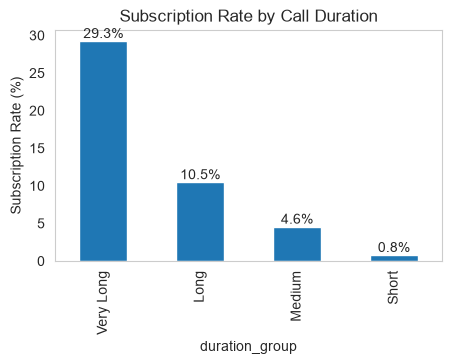

In [1514]:
# Visual duration
plt.figure(figsize=(5,3))

ax = duration_rate["yes"].sort_values(ascending=False).plot(kind="bar")

plt.title("Subscription Rate by Call Duration")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("duration_group")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [ ]:
# Find average durantion in minute
campaign["duration"].describe() / 60

count    712.533333
mean       4.296103
std        4.312978
min        0.000000
25%        1.700000
50%        2.983333
75%        5.316667
max       81.966667
Name: duration, dtype: float64

In [1531]:
campaign["duration_min"] = campaign["duration"] / 60

C:\Users\cecim\AppData\Local\Temp\ipykernel_8692\1308998045.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(campaign["duration_min"], vert=False, patch_artist=True,


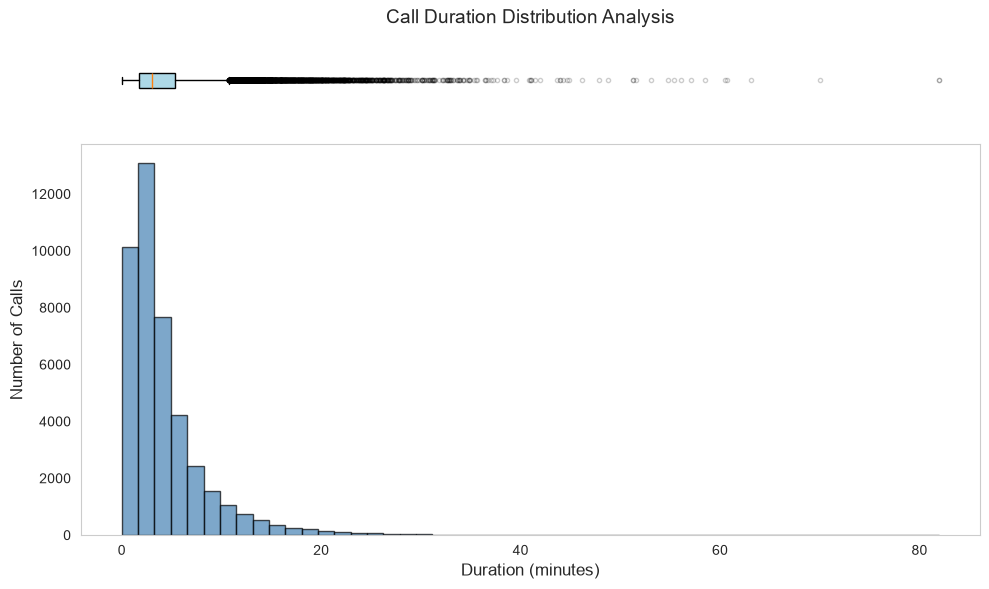

In [ ]:
# Visual

import matplotlib.pyplot as plt

# Create a figure with 2 subplots sharing the same X-axis
fig, (ax_box, ax_hist) = plt.subplots(2, 1, sharex=True, 
                                       gridspec_kw={"height_ratios": (0.2, 0.8)}, 
                                       figsize=(10, 6))

# 1. Top subplot: Boxplot
ax_box.boxplot(campaign["duration_min"], vert=False, patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               flierprops=dict(marker='o', alpha=0.2, markersize=3))
ax_box.set_title("Call Duration Distribution Analysis", fontsize=14)
ax_box.set_yticks([])
ax_box.axis('off') # Hide the borders of the boxplot sub-plot

# 2. Bottom subplot: Histogram
ax_hist.hist(campaign["duration_min"], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax_hist.set_xlabel("Duration (minutes)", fontsize=12)
ax_hist.set_ylabel("Number of Calls", fontsize=12)
ax_hist.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
campaign.groupby("duration_group")["duration_min"].agg(["min", "max", "mean"])

,min,max,mean
duration_group,,,
Long,3.000000,5.316667,3.987918
Medium,1.716667,2.983333,2.319592
Short,0.000000,1.700000,1.044718
Very Long,5.333333,81.966667,9.862159


**Observation:** The analysis show that the distribution of call duration contains several outliers. It is noticed that while the average call duration was approximately 4.3 minutes, a small number of calls extended well beyond the typical range, reaching a maximum duration of approximately 82 minutes. These extreme values indicate a highly right skewed distribution of call durations.
Among the call duration categories, the Very Long segment achieved the highest subscription conversion rate. Customers in this segment were engaged in calls lasting more than 5 minutes, with an average duration of nearly 10 minutes. This finding suggests a positive relationship between call duration and subscription success, indicating that longer customer interactions may increase the likelihood of a successful subscription outcome. However, it should be noted that call duration is measured after the interaction has taken place and therefore should be interpreted as an explanatory factor rather than a predictive one.

In [ ]:
# Contacts made previous to the campaign 
campaign["previous"].value_counts()
campaign["previous"].value_counts(normalize=True) * 100

previous
0    86.271987
1    11.124626
2     1.824476
3     0.542665
4     0.175430
5     0.046781
6     0.011695
7     0.002339
Name: proportion, dtype: float64

In [ ]:
# Previous campaign status

campaign["poutcome"].value_counts()
campaign["poutcome"].value_counts(normalize=True) * 100

poutcome
NONEXISTENT    86.271987
FAILURE        10.392496
SUCCESS         3.335516
Name: proportion, dtype: float64

**Observation:** The analysis of contacts made prior to the campaign and the previous campaign results provides limited insight into subscription behaviour. Approximately 86% of customers had not been contacted before the current campaign, and most previous campaign outcomes were recorded as non-existent. As a result, the dataset contains relatively few observations of customers with prior campaign interactions, limiting the ability to assess whether previous contact frequency or past campaign success had a meaningful influence on subscription outcomes.

<spen style="color:orange;">**Part 5 Final Conclusions**</spen>

*The analysis of the merged bank marketing campaign and customer datasets shows that the campaign achieved an overall subscription conversion rate of 11.25%, with 4,811 successful subscriptions out of 42,752 customer. Although the campaign generated a substantial number of conversions, the majority of customers (88.75%) did not subscribe, indicating opportunities to improve.*

**Customer Demographics**

Demographic characteristics were among the strongest predictors of subscription success.
 Customers aged 30 years or younger and 51 years or older achieved higher conversion rates than the middle-aged segment (31–50 years).
 Students and retired customers recorded the highest subscription rates among occupational groups. Single customers were more likely to subscribe than married or divorced customers.
 Customers with higher levels of education, particularly university graduates, generally demonstrated stronger subscription performance
   - These findings suggest that customer life stage and educational attainment may influence responsiveness to marketing campaigns.

**Social and Economic Factors**

 Most social and economic indicators showed only limited influence on subscription outcomes.
 Income level, housing loans, personal loans, and household composition produced relatively similar conversion rates across categories.
 Web activity levels showed almost no variation in conversion performance, indicating that browsing activity alone is not a reliable predictor of subscription likelihood.
 Customers with no history of payment default achieved higher subscription rates than customers with unknown or negative default status.

Overall, demographic characteristics appear to be more informative than socio-economic indicators for predicting campaign success.

**Marketing Campaign Factors**

 Marketing-related variables showed the strongest relationship with subscription outcomes.
 Customers contacted through the cellular channel achieved substantially higher conversion rates than those contacted by telephone.
 The highest conversion rates were observed during the first three contact attempts, with performance declining as additional contacts were made.
 Call duration emerged as the most influential campaign indicator. Longer conversations were associated with significantly higher subscription rates, suggesting that customer engagement during the interaction is strongly linked to campaign success.

 Previous campaign contacts and outcomes provided limited analytical value due to the large proportion of customers with no prior campaign history.

 **Key Business Insights**

 The results suggest that future campaigns should prioritize:
   - Targeting younger and older customer segments, particularly students and retirees;
   - Increasing the use of cellular as communication channels;
   - Focusing on high-quality customer interactions rather than increasing the number of contact attempts;
   - Limiting repeated outreach after three unsuccessful contacts;
   - Using demographic characteristics as primary segmentation variables when selecting campaign audiences.

**Final Assessment**

*The analysis indicates that marketing execution factors, particularly communication channel, number of contacts, and call duration, have a greater impact on subscription success than most socio-economic characteristics. While demographic factors help identify customer segments with higher conversion potential, the effectiveness of customer engagement during the campaign appears to be the primary driver of successful subscriptions. Future marketing efforts should therefore emphasize targeted customer selection combined with more efficient and personalized communication strategies.*